In [451]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [452]:
conn = sqlite3.connect("base_tratada.db")

query = """
SELECT *
FROM base_tratada;
"""

df = pd.read_sql(query, conn)

# Visualizar os dados
df.head()

#testando se o banco conectou



,preco,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,tipo_de_propriedade,latitude,longitude,...,banheiros,tipo_quarto_Entire home/apt,tipo_quarto_Hotel room,tipo_quarto_Private room,tipo_quarto_Shared room,tipo_de_propriedade_grupo,bairro_encode,ano_mes,ipca_mensal,ipca_acumulado_ano
0,580.0,4,2.0,3.0,4.93,2,86,entire condo,-22.982818,-43.222457,...,1.5,1,0,0,0,1,76,2025-09-01 00:00:00,0.0048,0.0426
1,1900.0,2,1.0,1.0,NaN,5,0,entire rental unit,-22.984090,-43.191770,...,2.0,1,0,0,0,1,34,2025-09-01 00:00:00,0.0048,0.0426
2,700.0,4,1.0,1.0,NaN,1,0,entire rental unit,-22.814911,-43.379011,...,1.0,1,0,0,0,1,96,2025-09-01 00:00:00,0.0048,0.0426
3,NaN,2,NaN,NaN,5.00,2,3,private room in rental unit,-22.981910,-43.225990,...,1.0,0,0,1,0,4,76,2025-09-01 00:00:00,0.0048,0.0426
4,500.0,4,1.0,1.0,4.91,2,11,entire rental unit,-23.010000,-43.344820,...,1.0,1,0,0,0,1,8,2025-09-01 00:00:00,0.0048,0.0426


In [453]:

df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   preco                        38670 non-null  float64
 1   hospedes                     43068 non-null  int64  
 2   quartos                      42096 non-null  float64
 3   camas                        38660 non-null  float64
 4   nota_avaliacao               33882 non-null  float64
 5   noites_minimas               43068 non-null  int64  
 6   quantidade_avaliacoes        43068 non-null  int64  
 7   tipo_de_propriedade          43068 non-null  str    
 8   latitude                     43068 non-null  float64
 9   longitude                    43068 non-null  float64
 10  bairro                       43068 non-null  str    
 11  ano                          43068 non-null  int64  
 12  mes                          43068 non-null  int64  
 13  banheiros                  

In [454]:
df["preco"].describe()

#antes do tratamento de outliers

count     38670.000000
mean        717.535325
std        4388.082802
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: preco, dtype: float64

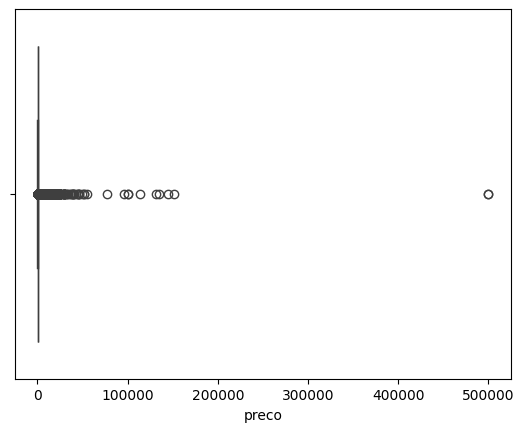

In [455]:
sns.boxplot(x=df["preco"])
plt.show()

plt.show()

#grafico para avaliar os outliers no dataframe sem tratamento dos outliers


In [456]:
#outliers
df["preco"].sort_values(ascending=False).head(20)
#verificando valores

7624     500000.0
15026    500000.0
16440    151710.0
21203    144800.0
13282    134358.0
42536    131400.0
24598    114118.0
14389    100000.0
13880    100000.0
27939     96547.0
3146      76956.0
1854      55394.0
24256     51545.0
18525     51429.0
24053     50000.0
10694     45900.0
12548     45818.0
34736     45000.0
24697     45000.0
4401      42924.0
Name: preco, dtype: float64

In [457]:
df_tratado = df[df["preco"] <= 7000].copy()

#Limita o preco das diaria ate 13k

In [458]:
df.shape[0], df_tratado.shape[0]

#mostra os dois dataframes

(43068, 38279)

In [459]:

print(f"Antes: {df.shape[0]} linhas")
print(f"Depois: {df_tratado.shape[0]} linhas")
print(f"Removidos: {df.shape[0] - df_tratado.shape[0]} linhas")


Antes: 43068 linhas
Depois: 38279 linhas
Removidos: 4789 linhas


In [460]:
df_tratado["preco"].describe()

count    38279.000000
mean       527.630189
std        692.222198
min         30.000000
25%        201.000000
50%        315.000000
75%        550.000000
max       7000.000000
Name: preco, dtype: float64

In [461]:
df["preco"].sort_values(ascending=True).head(20)

#mostra valores em forma crescente

5386     30.0
6624     39.0
9388     40.0
42145    41.0
10249    42.0
24389    43.0
11471    43.0
42673    44.0
21734    44.0
14333    46.0
27704    46.0
4048     46.0
8908     46.0
6474     47.0
22890    48.0
9135     48.0
9908     48.0
37698    48.0
7530     48.0
8598     48.0
Name: preco, dtype: float64

In [462]:

df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= 65) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()

#atribui ao novo dataframe valores de limete pós remocao de outliers



In [463]:
print(df_tratado_price_min["preco"].quantile([0.90, 0.95, 0.99, 1.0]))

0.90    1028.0
0.95    1632.0
0.99    4000.0
1.00    7000.0
Name: preco, dtype: float64


In [464]:
print(f"Antes: {df_tratado.shape[0]} linhas")
print(f"Depois: {df_tratado_price_min.shape[0]} linhas")
print(f"Removidos: {df_tratado.shape[0] - df_tratado_price_min.shape[0]} linhas")

Antes: 38279 linhas
Depois: 37711 linhas
Removidos: 568 linhas


In [465]:
df_tratado_price_min["preco"].describe()

count    37711.000000
mean       531.505105
std        693.419011
min         65.000000
25%        204.000000
50%        316.000000
75%        553.000000
max       7000.000000
Name: preco, dtype: float64

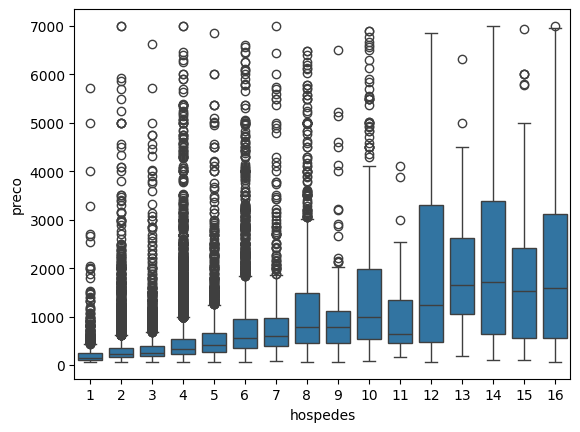

In [466]:
sns.boxplot(x="hospedes", y="preco", data=df_tratado_price_min)
plt.show()

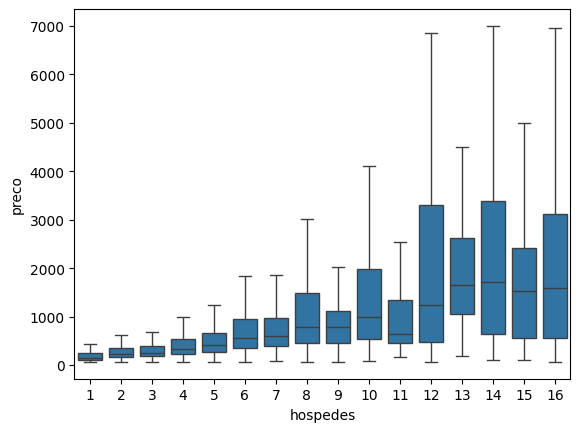

In [467]:
sns.boxplot(x="hospedes", y="preco", data=df_tratado_price_min, showfliers=False)
plt.show()

In [468]:

print("Registros originais:", len(df_tratado))
print("Registros após remoção de outliers:", len(df_tratado_price_min))


Registros originais: 38279
Registros após remoção de outliers: 37711


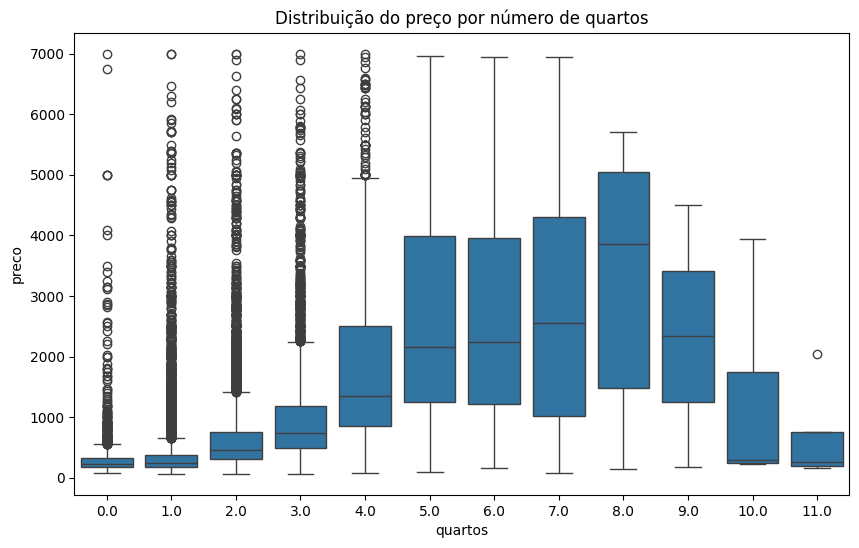

In [469]:


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="quartos",
    y="preco"
)

plt.title("Distribuição do preço por número de quartos")
plt.xlim(-0.5, 11.5)
plt.show()



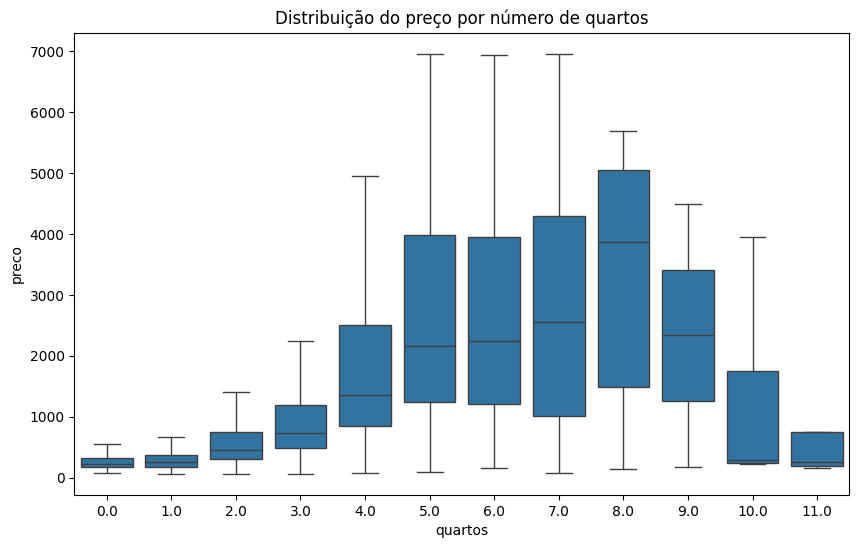

In [470]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="quartos",
    y="preco",
    showfliers=False
)

plt.title("Distribuição do preço por número de quartos")
plt.xlim(-0.5, 11.5)
plt.show()



In [471]:
df_box_banheiros = df_tratado_price_min[df_tratado_price_min["banheiros"] <=10].copy()

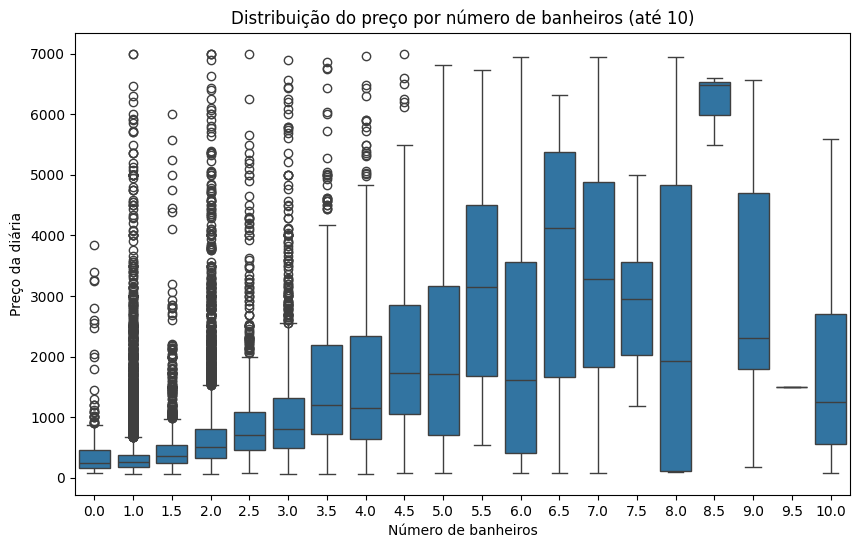

In [472]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_box_banheiros,
    x="banheiros",
    y="preco"
)

plt.title("Distribuição do preço por número de banheiros (até 10)")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária")

plt.show()


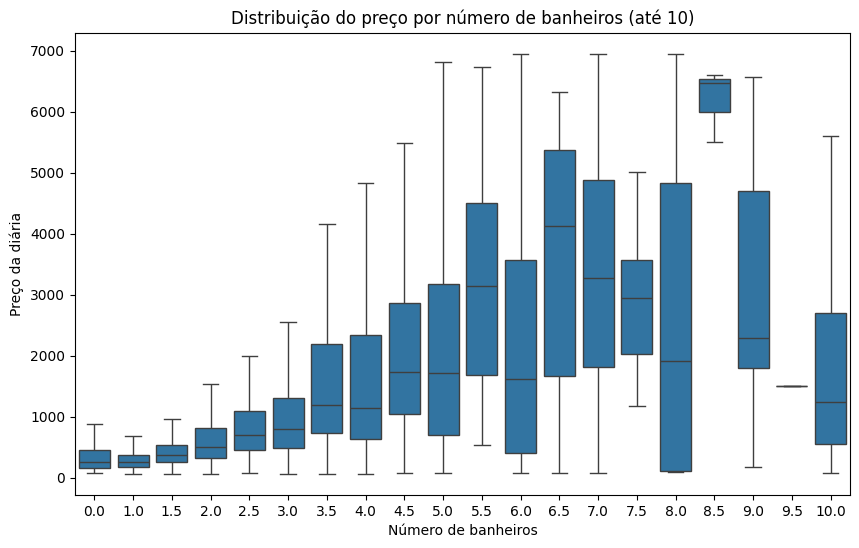

In [473]:


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_box_banheiros,
    x="banheiros",
    y="preco",
    showfliers=False
)

plt.title("Distribuição do preço por número de banheiros (até 10)")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária")

plt.show()



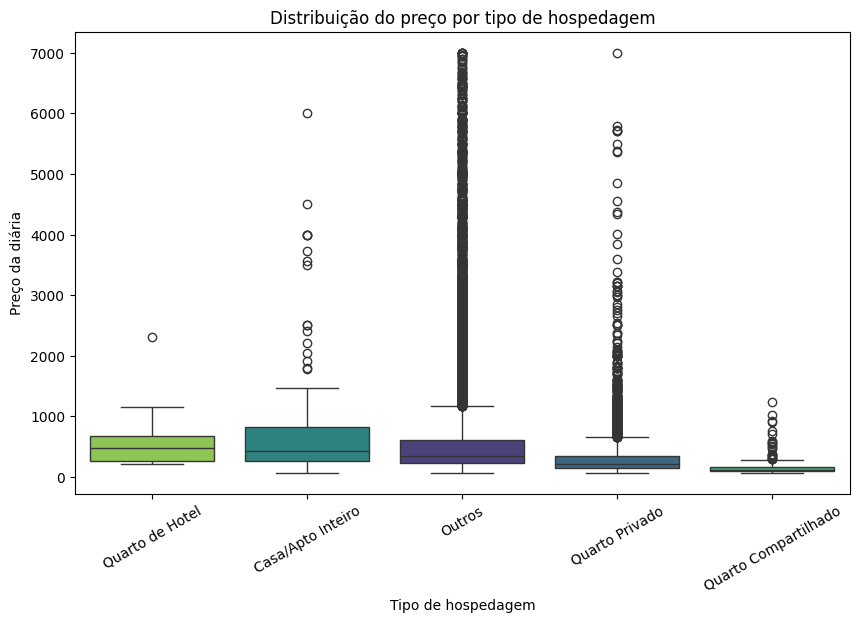

In [474]:

mapa_tipos = {
    "tipo_quarto_Entire home/apt": "Casa/Apto Inteiro",
    "tipo_quarto_Hotel room": "Quarto de Hotel",
    "tipo_quarto_Private room": "Quarto Privado",
    "tipo_quarto_Shared room": "Quarto Compartilhado",
    "tipo_de_propriedade_grupo": "Outros"
}

df_boxplot = df_tratado_price_min.copy()

df_boxplot["Tipo de hospedagem"] = None

for coluna, nome in mapa_tipos.items():
    df_boxplot.loc[df_boxplot[coluna] == 1, "Tipo de hospedagem"] = nome


ordem = (
    df_boxplot
    .groupby("Tipo de hospedagem")["preco"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_boxplot,
    x="Tipo de hospedagem",
    y="preco",
    order=ordem,
    hue="Tipo de hospedagem",
    palette="viridis",
    legend=False
)

plt.title("Distribuição do preço por tipo de hospedagem")
plt.xlabel("Tipo de hospedagem")
plt.ylabel("Preço da diária")
plt.xticks(rotation=30)
plt.show()



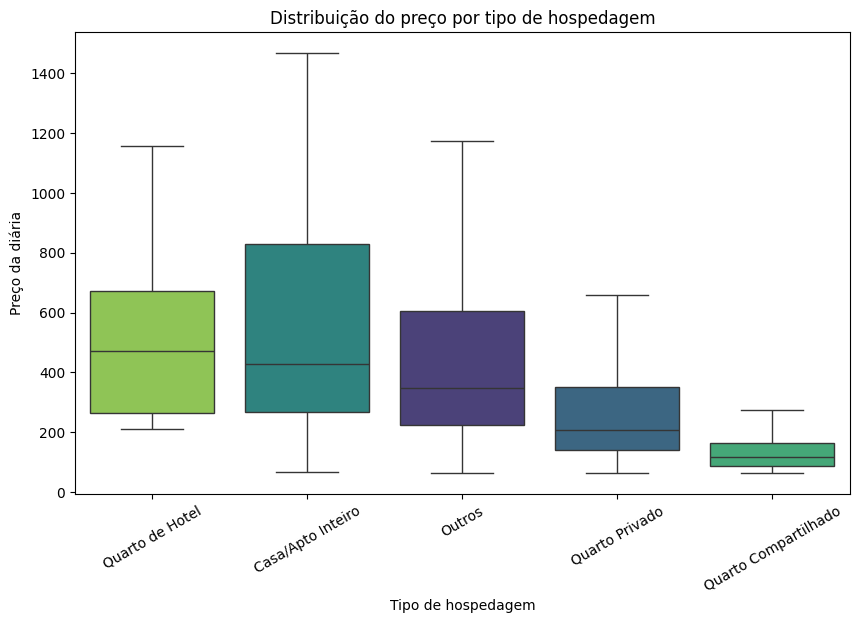

In [475]:

ordem = (
    df_boxplot
    .groupby("Tipo de hospedagem")["preco"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_boxplot,
    x="Tipo de hospedagem",
    y="preco",
    order=ordem,
    hue="Tipo de hospedagem",
    palette="viridis",
    legend=False,
    showfliers=False
)

plt.title("Distribuição do preço por tipo de hospedagem")
plt.xlabel("Tipo de hospedagem")
plt.ylabel("Preço da diária")
plt.xticks(rotation=30)
plt.show()


In [476]:

df_tratado_price_min[
    [
        "preco",
        "hospedes",
        "quartos",
        "camas",
        "nota_avaliacao",
        "noites_minimas",
        "quantidade_avaliacoes",
        "latitude",
        "longitude",
        "banheiros",
        "tipo_quarto_Entire home/apt",
        "tipo_quarto_Hotel room",
        "tipo_quarto_Private room",
        "tipo_quarto_Shared room"
    ]
].describe()


,preco,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,latitude,longitude,banheiros,tipo_quarto_Entire home/apt,tipo_quarto_Hotel room,tipo_quarto_Private room,tipo_quarto_Shared room
count,37711.000000,37711.000000,37711.000000,37700.000000,30097.000000,37711.000000,37711.000000,37711.000000,37711.000000,37711.000000,37711.000000,37711.000000,37711.000000,37711.000000
mean,531.505105,3.950200,1.482432,2.340371,4.814051,3.421044,27.975498,-22.965898,-43.248241,1.460250,0.817825,0.000398,0.174087,0.007690
std,693.419011,2.222952,0.906562,1.974669,0.351973,13.274533,50.407864,0.035845,0.101286,0.864768,0.385994,0.019940,0.379189,0.087356
min,65.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-23.072920,-43.713593,0.000000,0.000000,0.000000,0.000000,0.000000
25%,204.000000,2.000000,1.000000,1.000000,4.770000,1.000000,1.000000,-22.984263,-43.300708,1.000000,1.000000,0.000000,0.000000,0.000000
50%,316.000000,4.000000,1.000000,2.000000,4.920000,2.000000,8.000000,-22.971740,-43.193360,1.000000,1.000000,0.000000,0.000000,0.000000
75%,553.000000,5.000000,2.000000,3.000000,5.000000,3.000000,33.000000,-22.952714,-43.184319,2.000000,1.000000,0.000000,0.000000,0.000000
max,7000.000000,16.000000,15.000000,50.000000,5.000000,730.000000,760.000000,-22.750510,-43.104400,12.000000,1.000000,1.000000,1.000000,1.000000


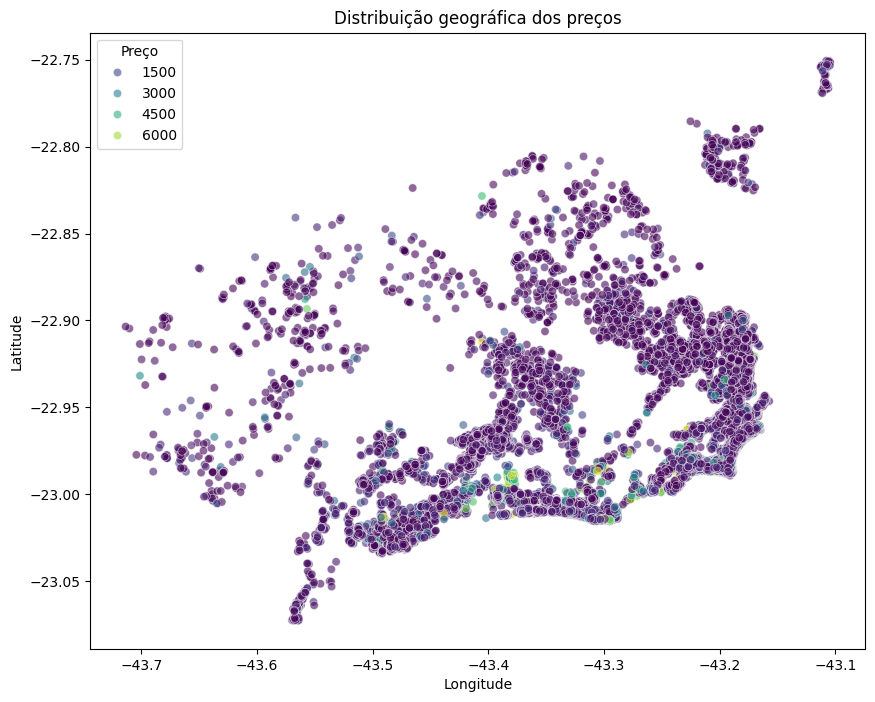

In [477]:

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_tratado_price_min,
    x="longitude",
    y="latitude",
    hue="preco",
    palette="viridis",
    alpha=0.6
)

plt.title("Distribuição geográfica dos preços")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Preço", loc="best")
plt.show()


In [478]:

df_tratado_price_min["lat_bin"] = df_tratado_price_min["latitude"].round(2)
df_tratado_price_min["lon_bin"] = df_tratado_price_min["longitude"].round(2)


In [479]:

media_localizacao = (
    df_tratado_price_min
    .groupby(["lat_bin", "lon_bin"])["preco"]
    .mean()
    .reset_index()
)


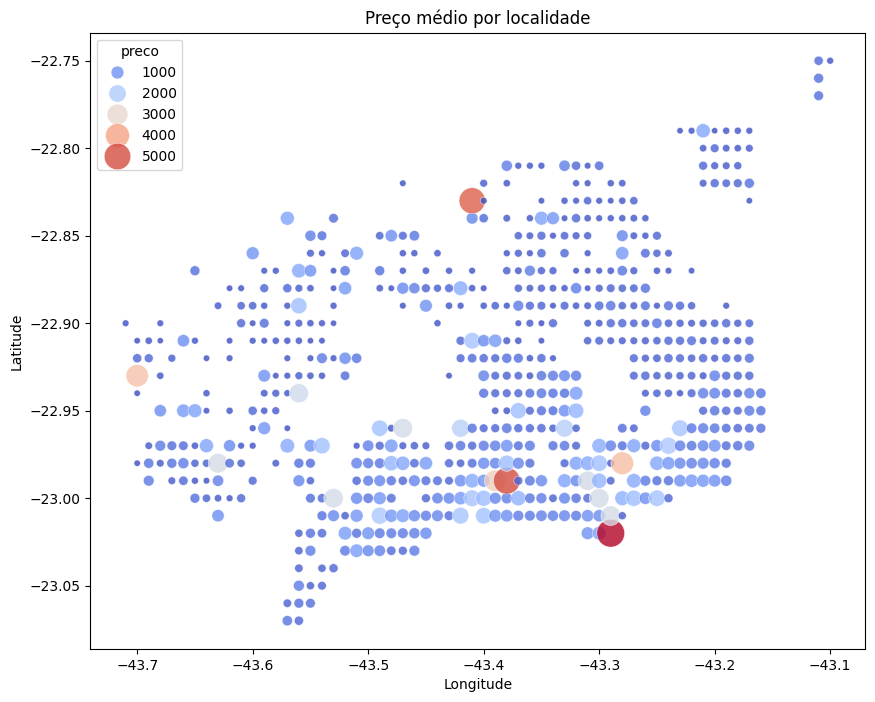

In [480]:

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=media_localizacao,
    x="lon_bin",
    y="lat_bin",
    size="preco",
    hue="preco",
    palette="coolwarm",
    sizes=(20, 400),
    alpha=0.8
)

plt.title("Preço médio por localidade")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [481]:

tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room"
}



In [482]:

frequencias = []
total_registros = len(df_tratado_price_min)

for nome, coluna in tipos_imovel.items():
    freq_absoluta = df_tratado_price_min[coluna].sum()
    freq_relativa = freq_absoluta / total_registros

    frequencias.append({
        "Tipo de imóvel": nome,
        "Frequência relativa": freq_relativa
    })

df_frequencia = pd.DataFrame(frequencias)
df_frequencia["Frequência (%)"] = df_frequencia["Frequência relativa"] * 100

# =========================
# TABELA FINAL
# =========================

df_frequencia



,Tipo de imóvel,Frequência relativa,Frequência (%)
0,Casa/apt Inteiro,0.817825,81.782504
1,Quarto de Hotel,0.000398,0.039776
2,Quarto Privado,0.174087,17.408714
3,Quarto Compartilhado,0.007690,0.769006


In [483]:
tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room",
    "Outros": "tipo_de_propriedade_grupo"
}


In [484]:
media_precos = []

for nome, coluna in tipos_imovel.items():
    preco_medio = df_tratado_price_min.loc[
        df_tratado_price_min[coluna] == 1, "preco"
    ].mean()
    
    media_precos.append({
        "Tipo de imóvel": nome,
        "Preço médio": preco_medio
    })

df_media = pd.DataFrame(media_precos)




df_media


,Tipo de imóvel,Preço médio
0,Casa/apt Inteiro,580.747771
1,Quarto de Hotel,619.800000
2,Quarto Privado,316.501904
3,Quarto Compartilhado,157.293103
4,Outros,579.874450


C:\Users\GY428MP\AppData\Local\Temp\ipykernel_28336\2724522762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


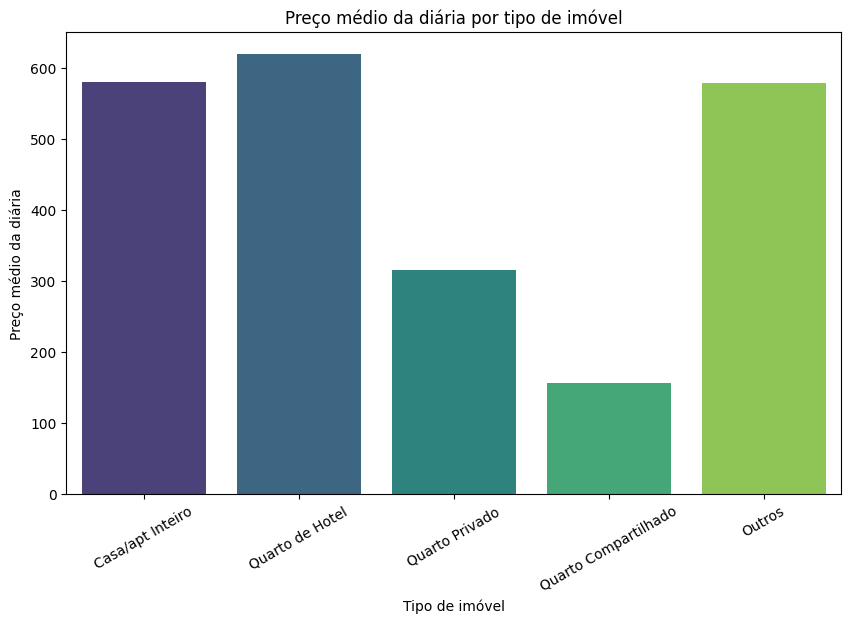

In [485]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media,
    x="Tipo de imóvel",
    y="Preço médio",
    palette="viridis"
)

df_media = df_media.sort_values(
    by="Preço médio",
    ascending=False
)

plt.title("Preço médio da diária por tipo de imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Preço médio da diária")
plt.xticks(rotation=30)
plt.show()


C:\Users\GY428MP\AppData\Local\Temp\ipykernel_28336\2823616199.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


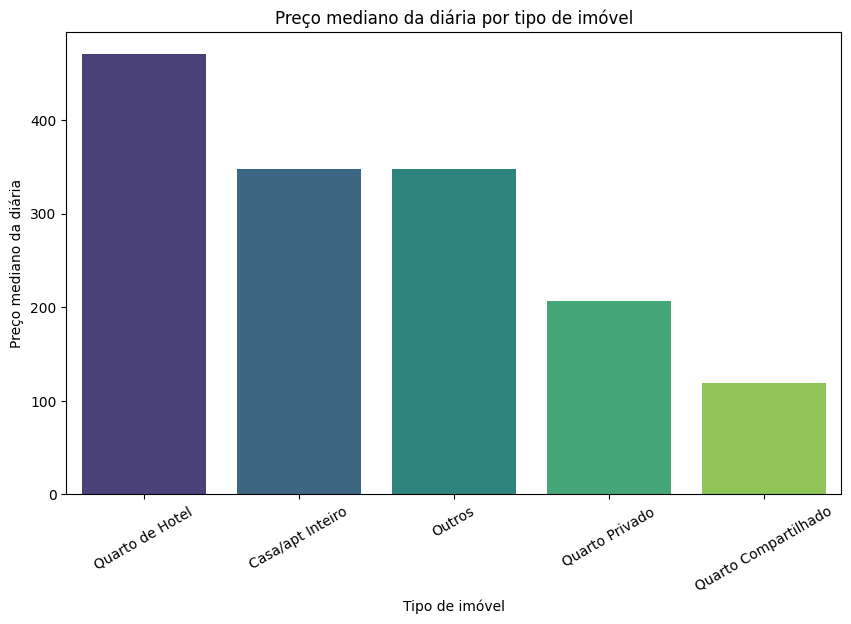

In [486]:
tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room",
    "Outros": "tipo_de_propriedade_grupo"
}



mediana_precos = []

for nome, coluna in tipos_imovel.items():
    preco_mediano = df_tratado_price_min.loc[
        df_tratado_price_min[coluna] == 1, "preco"
    ].median()
    
    mediana_precos.append({
        "Tipo de imóvel": nome,
        "Preço mediano": preco_mediano
    })

df_mediana = pd.DataFrame(mediana_precos)

df_mediana


df_mediana = df_mediana.sort_values(
    by="Preço mediano",
    ascending=False
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mediana,
    x="Tipo de imóvel",
    y="Preço mediano",
    palette="viridis"
)

plt.title("Preço mediano da diária por tipo de imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Preço mediano da diária")
plt.xticks(rotation=30)
plt.show()




In [487]:
df_tratado_price_min[df_tratado_price_min["bairro"] == "Copacabana"]["preco"].mean()

np.float64(475.0061401295315)

In [488]:

top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)


In [489]:

df_media_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .mean()
    .reset_index()
)

# manter apenas bairros mais procurados
df_media_acomodacao = df_media_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


In [490]:

df_media_acomodacao = df_media_acomodacao.sort_values("preco", ascending=False)


C:\Users\GY428MP\AppData\Local\Temp\ipykernel_28336\2460075909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


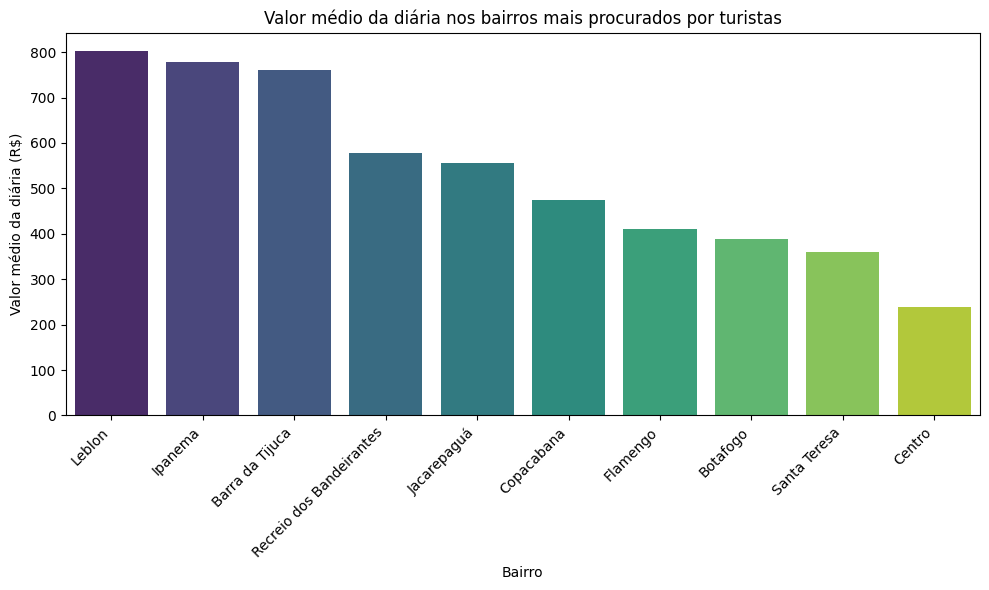

In [491]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Valor médio da diária nos bairros mais procurados por turistas")
plt.xlabel("Bairro")
plt.ylabel("Valor médio da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


C:\Users\GY428MP\AppData\Local\Temp\ipykernel_28336\4196697961.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


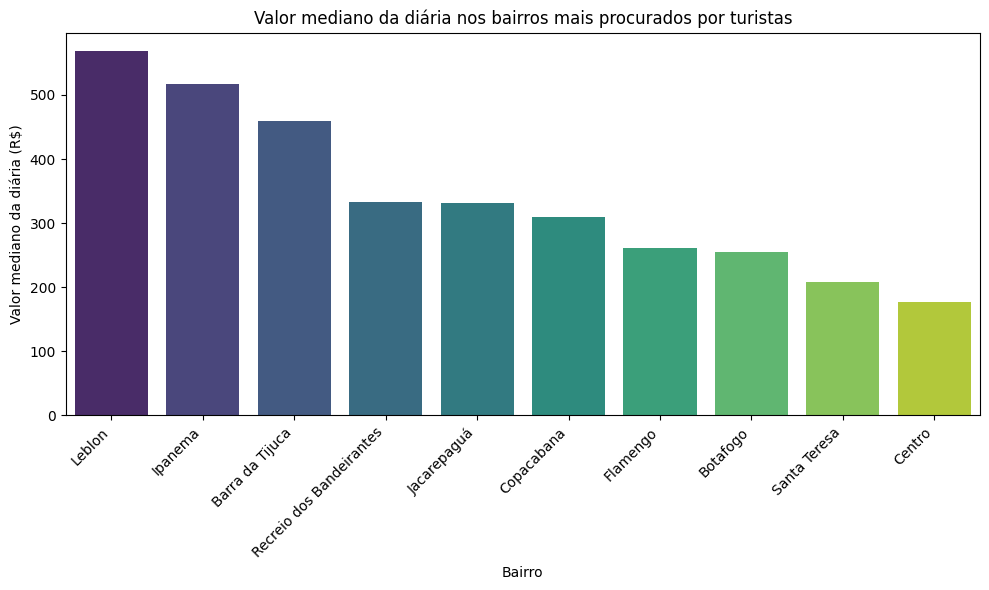

In [492]:

top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)


df_mediana_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .median()
    .reset_index()
)


df_mediana_acomodacao = df_mediana_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


df_mediana_acomodacao = df_mediana_acomodacao.sort_values(
    "preco",
    ascending=False
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mediana_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Valor mediano da diária nos bairros mais procurados por turistas")
plt.xlabel("Bairro")
plt.ylabel("Valor mediano da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()




C:\Users\GY428MP\AppData\Local\Temp\ipykernel_28336\3330698642.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


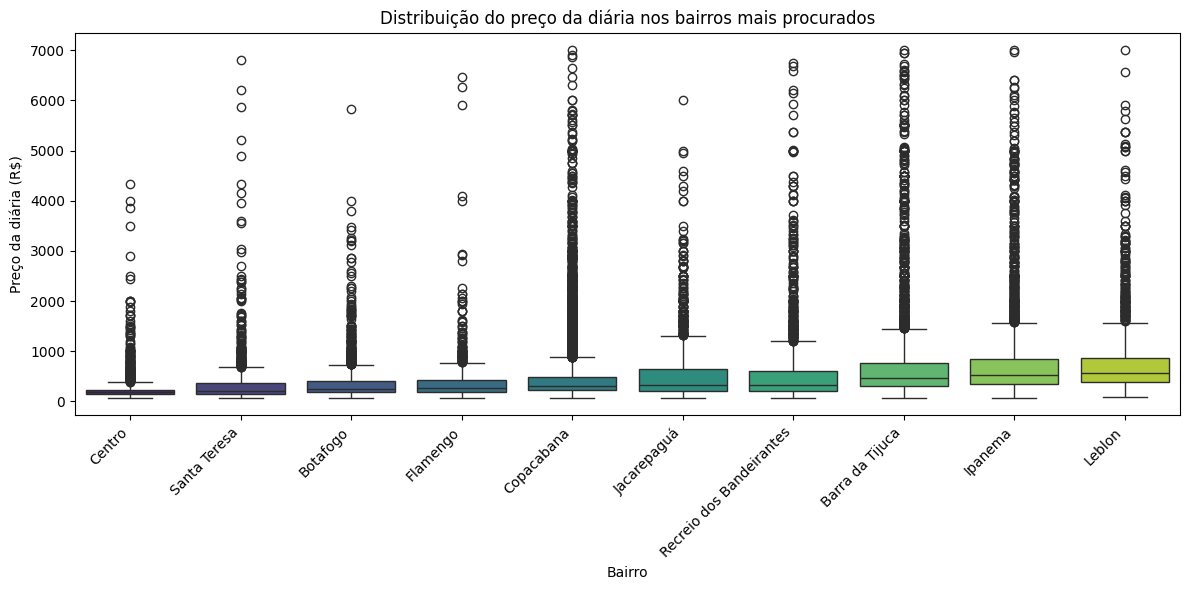

In [493]:

df_top_bairros = df_tratado_price_min.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


ordem_bairros = (
    df_top_bairros
    .groupby("bairro")["preco"]
    .median()
    .sort_values()
    .index
)


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_bairros,
    x="bairro",
    y="preco",
    order=ordem_bairros,
    palette="viridis"
)

plt.title("Distribuição do preço da diária nos bairros mais procurados")
plt.xlabel("Bairro")
plt.ylabel("Preço da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



C:\Users\GY428MP\AppData\Local\Temp\ipykernel_28336\3611848364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


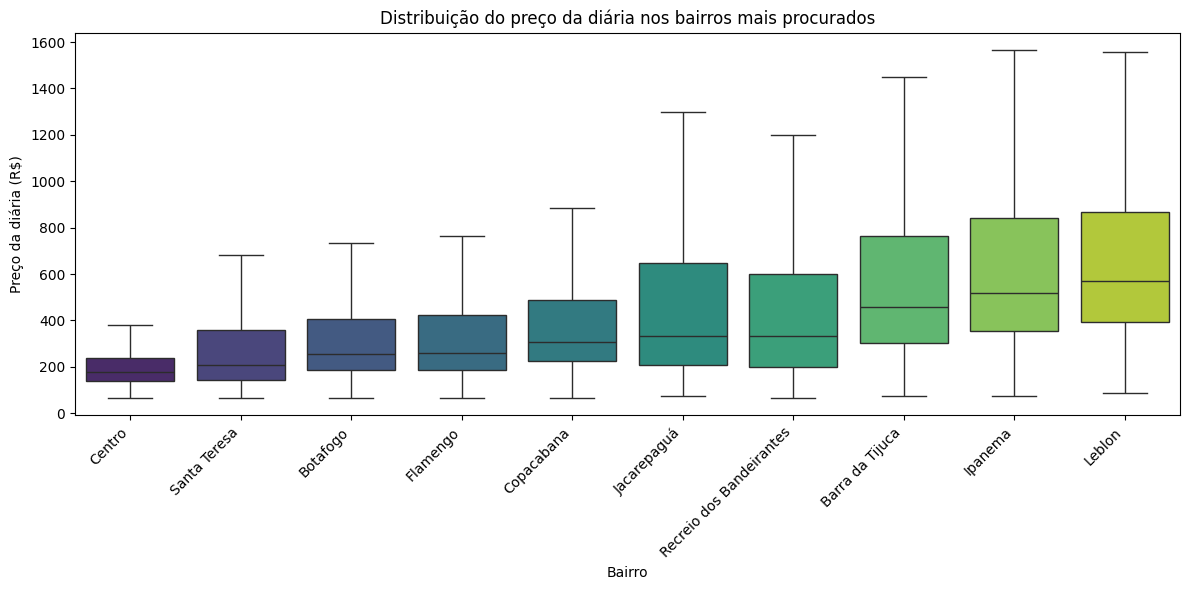

In [494]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_bairros,
    x="bairro",
    y="preco",
    order=ordem_bairros,
    palette="viridis",
    showfliers=False
)

plt.title("Distribuição do preço da diária nos bairros mais procurados")
plt.xlabel("Bairro")
plt.ylabel("Preço da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [495]:

variaveis = [
    "preco",
    "quartos",
    "banheiros",
    "latitude",
    "longitude",
    "camas",
    "nota_avaliacao",
    "quantidade_avaliacoes",
    "tipo_quarto_Entire home/apt",
    "tipo_quarto_Hotel room",
    "tipo_quarto_Private room",
    "tipo_quarto_Shared room"
]

df_corr = df_tratado_price_min[variaveis]


In [496]:
corr_matrix = df_corr.corr()

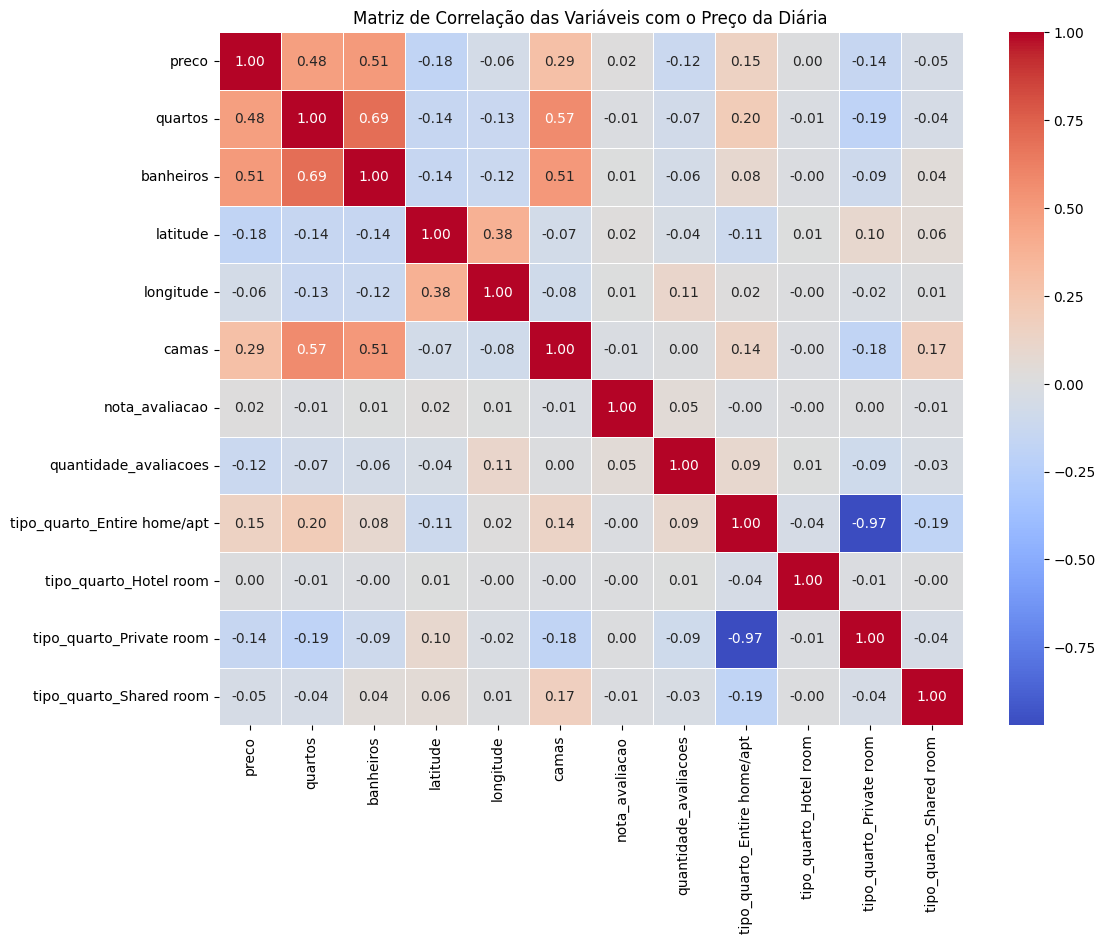

In [497]:

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis com o Preço da Diária")
plt.show()


Treinando algoritmo

 "latitude",
    "longitude",
    "quartos",
    "banheiros",
    "camas",
    "tipo_quarto_Entire home/apt",
    "tipo_quarto_Hotel room",
    "tipo_quarto_Private room",
    "tipo_quarto_Shared room",
    "nota_avaliacao",
    "quantidade avaliações"

### Modelo sem transformação log (baseline)

In [498]:
# Base final definida a partir da análise exploratória

df_modelo = df_tratado_price_min.copy()

In [499]:
# Ajuste do preço pela inflação (IPCA)

df_modelo["preco_ajustado"] = (
    df_modelo["preco"] * (1 + df_modelo["ipca_acumulado_ano"])
)

In [500]:
# Seleção das variáveis definidas na EDA

variaveis_modelo = [
    "preco_ajustado",
    "latitude",
    "longitude",
    "quartos",
    "banheiros",
    "camas",
    "tipo_quarto_Entire home/apt",
    "tipo_quarto_Hotel room",
    "tipo_quarto_Private room",
    "tipo_quarto_Shared room",
    "nota_avaliacao",
    "quantidade_avaliacoes"
]

df_modelo = df_modelo[variaveis_modelo]

In [501]:
# Quantidade de valores nulos por coluna

df_modelo.isna().sum()

preco_ajustado                    0
latitude                          0
longitude                         0
quartos                           0
banheiros                         0
camas                            11
tipo_quarto_Entire home/apt       0
tipo_quarto_Hotel room            0
tipo_quarto_Private room          0
tipo_quarto_Shared room           0
nota_avaliacao                 7614
quantidade_avaliacoes             0
dtype: int64

In [502]:
# Remoção de valores ausentes

df_modelo = df_modelo.dropna()

In [503]:
X = df_modelo.drop("preco_ajustado", axis=1)
y = df_modelo["preco_ajustado"]

In [504]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [505]:
from sklearn.ensemble import RandomForestRegressor

modelo_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

modelo_baseline.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [506]:
y_pred = modelo_baseline.predict(X_test)

In [507]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline sem log")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Baseline sem log
MAE: 206.4132549359853
RMSE: 457.80858407750367
R²: 0.38574322423903784


### Modelo com transformação log

In [508]:
# Transformação logarítmica do preço ajustado

df_modelo["preco_log"] = np.log1p(df_modelo["preco_ajustado"])

In [509]:
X_log = df_modelo.drop(
    ["preco_ajustado", "preco_log"],
    axis=1
)

y_log = df_modelo["preco_log"]

In [510]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,
    y_log,
    test_size=0.2,
    random_state=42
)

In [511]:
modelo_log = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

modelo_log.fit(X_train_log, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [512]:
y_pred_log = modelo_log.predict(X_test_log)

In [513]:
# Converter valores de volta para reais

y_pred_log_reais = np.expm1(y_pred_log)
y_test_reais = np.expm1(y_test_log)

In [514]:
mae_log = mean_absolute_error(y_test_reais, y_pred_log_reais)
rmse_log = np.sqrt(mean_squared_error(y_test_reais, y_pred_log_reais))
r2_log = r2_score(y_test_reais, y_pred_log_reais)

print("Modelo com transformação log")
print("MAE:", mae_log)
print("RMSE:", rmse_log)
print("R²:", r2_log)

Modelo com transformação log
MAE: 184.5919799407605
RMSE: 452.58532685127244
R²: 0.39967969637167966


### Comparação entre os modelos

A tabela abaixo apresenta a comparação entre o modelo baseline (sem transformação log)
e o modelo com transformação logarítmica do preço, utilizando as métricas MAE, RMSE e R².

In [515]:

# Cria a tabela de comparação

from IPython.display import display
import pandas as pd

comparacao = pd.DataFrame({
    "Modelo": ["Sem log", "Com log"],
    "MAE": [mae, mae_log],
    "RMSE": [rmse, rmse_log],
    "R²": [r2, r2_log]
})


In [516]:
# Mostrar a tabela
display(comparacao)

# Comparação automática baseada no MAE
melhor_com_log = mae_log < mae

if melhor_com_log:
    print("✅ O modelo com transformação log apresentou melhor desempenho em MAE.")
else:
    print("ℹ️ O modelo sem log apresentou desempenho semelhante ou melhor em MAE.")

,Modelo,MAE,RMSE,R²
0,Sem log,206.413255,457.808584,0.385743
1,Com log,184.591980,452.585327,0.399680


✅ O modelo com transformação log apresentou melhor desempenho em MAE.
